## import required libraries


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### import dataset

In [3]:
data=pd.read_csv("Sales-Data-Analysis.csv")

In [4]:
data.head()


,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,07-11-2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London
1,10453,07-11-2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid
2,10454,07-11-2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon
3,10455,08-11-2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin
4,10456,08-11-2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin


In [5]:
data.info

<bound method DataFrame.info of      Order ID        Date             Product  Price  Quantity Purchase Type  \
0       10452  07-11-2022               Fries   3.49    573.07       Online    
1       10453  07-11-2022           Beverages   2.95    745.76       Online    
2       10454  07-11-2022       Sides & Other   4.99    200.40     In-store    
3       10455  08-11-2022             Burgers  12.99    569.67     In-store    
4       10456  08-11-2022  Chicken Sandwiches   9.95    201.01     In-store    
..        ...         ...                 ...    ...       ...           ...   
249     10709  28-12-2022       Sides & Other   4.99    200.40   Drive-thru    
250     10710  29-12-2022             Burgers  12.99    754.43   Drive-thru    
251     10711  29-12-2022  Chicken Sandwiches   9.95    281.41   Drive-thru    
252     10712  29-12-2022               Fries   3.49    630.37   Drive-thru    
253     10713  29-12-2022           Beverages   2.95    677.97   Drive-thru    

    Pay

## consider the manager columns

In [6]:
data.Manager

0        Tom      Jackson
1             Pablo Perez
2           Joao    Silva
3           Walter Muller
4           Walter Muller
              ...        
249         Walter Muller
250         Walter Muller
251         Walter Muller
252         Walter Muller
253         Walter Muller
Name: Manager, Length: 254, dtype: object

In [7]:
data.Manager.unique()

array(['Tom      Jackson', '       Pablo Perez', 'Joao    Silva',
       'Walter Muller', 'Remy    Monet', 'Remy Monet',
       '       Remy Monet', 'Remy     Monet', 'Pablo Perez',
       'Pablo   Perez', 'Pablo  Perez', 'Pablo    Perez', 'Joao Silva',
       'Tom Jackson'], dtype=object)

In [9]:
data.Manager.nunique()

14

In [10]:
data['Manager'].str.strip().str.replace(r'\s+',' ',regex=True)

0        Tom Jackson
1        Pablo Perez
2         Joao Silva
3      Walter Muller
4      Walter Muller
           ...      
249    Walter Muller
250    Walter Muller
251    Walter Muller
252    Walter Muller
253    Walter Muller
Name: Manager, Length: 254, dtype: object

In [12]:
data.Manager=data['Manager'].str.strip().str.replace(r'\s+',' ',regex=True)

In [14]:
data.Manager.nunique()

5

In [15]:
data.Manager.unique()

array(['Tom Jackson', 'Pablo Perez', 'Joao Silva', 'Walter Muller',
       'Remy Monet'], dtype=object)

## Removing duplicates records

In [16]:
data.describe()

,Order ID,Price,Quantity
count,254.000000,254.000000,254.000000
mean,10584.133858,7.102323,460.611457
std,75.889181,4.341855,214.888699
min,10452.000000,2.950000,200.400000
25%,10520.250000,3.490000,201.010000
50%,10583.500000,4.990000,538.880000
75%,10649.750000,9.950000,677.440000
max,10713.000000,29.050000,754.430000


In [20]:
data[data.duplicated()]

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City


In [21]:
## Therefore there is no duplicates

In [23]:
data[data['Order ID'].duplicated()]

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City


## converting datatypes of the coluns

In [24]:
data.dtypes

Order ID            int64
Date               object
Product            object
Price             float64
Quantity          float64
Purchase Type      object
Payment Method     object
Manager            object
City               object
dtype: object

In [26]:
# data.columnName=data.columnName.astype(type eg float)

In [27]:
data.Quantity

0      573.07
1      745.76
2      200.40
3      569.67
4      201.01
        ...  
249    200.40
250    754.43
251    281.41
252    630.37
253    677.97
Name: Quantity, Length: 254, dtype: float64

In [32]:
data.Quantity=data.Quantity.round()

In [34]:
data.Quantity=data.Quantity.astype(int)

In [36]:
data.Quantity

0      573
1      746
2      200
3      570
4      201
      ... 
249    200
250    754
251    281
252    630
253    678
Name: Quantity, Length: 254, dtype: int64

In [37]:
data.dtypes

Order ID            int64
Date               object
Product            object
Price             float64
Quantity            int64
Purchase Type      object
Payment Method     object
Manager            object
City               object
dtype: object

In [45]:
data.Date=pd.to_datetime(data.Date,format='mixed')

In [46]:
data.dtypes

Order ID                   int64
Date              datetime64[ns]
Product                   object
Price                    float64
Quantity                   int64
Purchase Type             object
Payment Method            object
Manager                   object
City                      object
dtype: object

In [47]:
data.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,2022-07-11,Fries,3.49,573,Online,Gift Card,Tom Jackson,London
1,10453,2022-07-11,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid
2,10454,2022-07-11,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon
3,10455,2022-08-11,Burgers,12.99,570,In-store,Credit Card,Walter Muller,Berlin
4,10456,2022-08-11,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin


## Analyze Data

### Q1.What is the most preffered payment method

In [49]:
data.head(2)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,2022-07-11,Fries,3.49,573,Online,Gift Card,Tom Jackson,London
1,10453,2022-07-11,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid


In [51]:
data['Payment Method'].unique()

array([' Gift Card', ' Credit Card', ' Cash'], dtype=object)

In [53]:
data.groupby('Payment Method')['Payment Method'].value_counts()

Payment Method
Cash            76
Credit Card    120
Gift Card       58
Name: count, dtype: int64

In [ ]:
data.groupby('Payment Method')['Payment Method'].value_counts()

In [54]:
data['Payment Method'].value_counts()


Payment Method
Credit Card    120
Cash            76
Gift Card       58
Name: count, dtype: int64

In [55]:
#check in percentage
data['Payment Method'].value_counts(normalize=True)*100

Payment Method
Credit Card    47.244094
Cash           29.921260
Gift Card      22.834646
Name: proportion, dtype: float64

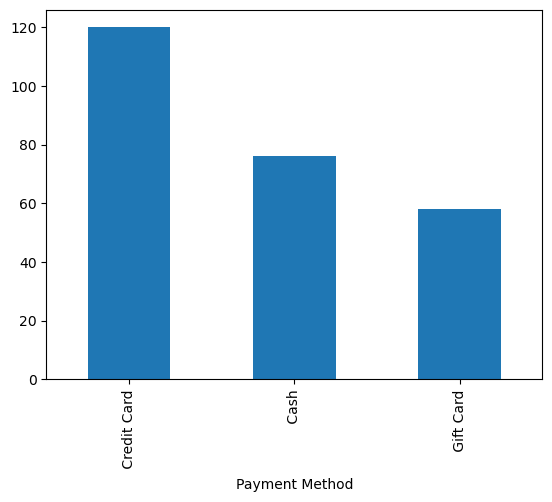

In [57]:
data['Payment Method'].value_counts().plot(kind='bar');

## Q.2 Most selling Product

- By Quantity
- By Revenue

In [58]:
data.head(2)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,2022-07-11,Fries,3.49,573,Online,Gift Card,Tom Jackson,London
1,10453,2022-07-11,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid


In [60]:
data.groupby('Product')['Quantity'].sum().sort_values(ascending=False)

Product
Beverages             34988
Fries                 32023
Burgers               29018
Chicken Sandwiches    11133
Sides & Other          9800
Name: Quantity, dtype: int64

In [62]:
most_quantity=data.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
most_quantity

Product
Beverages             34988
Fries                 32023
Burgers               29018
Chicken Sandwiches    11133
Sides & Other          9800
Name: Quantity, dtype: int64

In [63]:
type(most_quantity)

pandas.core.series.Series

In [66]:
most_quantity=most_quantity.reset_index()

In [67]:
most_quantity

,Product,Quantity
0,Beverages,34988
1,Fries,32023
2,Burgers,29018
3,Chicken Sandwiches,11133
4,Sides & Other,9800


Text(0, 0.5, 'Quantity')

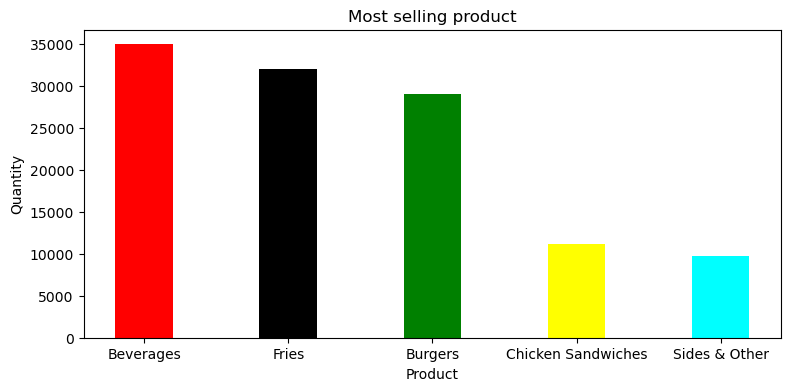

In [74]:
plt.figure(figsize=(9,4))
plt.bar(most_quantity.Product,most_quantity.Quantity,color=['red','black', 'green','yellow','cyan'],width=.4);
plt.title('Most selling product')
plt.xlabel('Product')
plt.ylabel('Quantity')


In [75]:
data['Revenue']=data.Price*data.Quantity

In [76]:
data.head(3)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue
0,10452,2022-07-11,Fries,3.49,573,Online,Gift Card,Tom Jackson,London,1999.77
1,10453,2022-07-11,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid,2200.70
2,10454,2022-07-11,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon,998.00


In [77]:
data.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

Product
Burgers               376943.82
Fries                 125626.57
Chicken Sandwiches    114612.45
Beverages             103214.60
Sides & Other          48902.00
Name: Revenue, dtype: float64

In [78]:
most_revenue=data.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
most_revenue

Product
Burgers               376943.82
Fries                 125626.57
Chicken Sandwiches    114612.45
Beverages             103214.60
Sides & Other          48902.00
Name: Revenue, dtype: float64

In [79]:
type(most_revenue)

pandas.core.series.Series

In [80]:
most_revenue=most_revenue.reset_index()

In [81]:
most_revenue

,Product,Revenue
0,Burgers,376943.82
1,Fries,125626.57
2,Chicken Sandwiches,114612.45
3,Beverages,103214.60
4,Sides & Other,48902.00


Text(0, 0.5, 'Revenue')

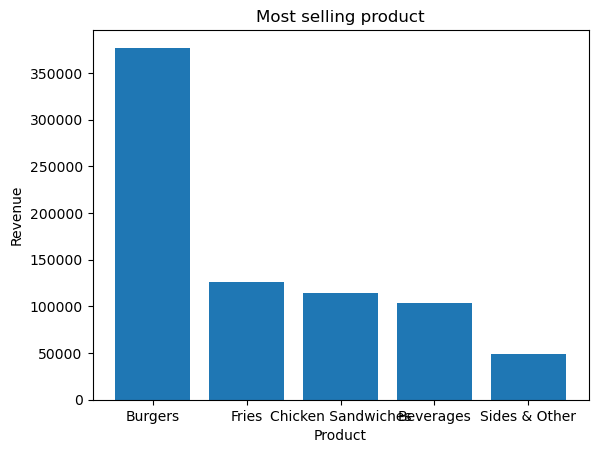

In [84]:

plt.bar(most_revenue.Product,most_revenue.Revenue);
plt.title('Most selling product')
plt.xlabel('Product')
plt.ylabel('Revenue')

### Q.3 Which city had maxumum revenue
### or 
### Which manager earned maximum revenue

In [86]:
data.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue
0,10452,2022-07-11,Fries,3.49,573,Online,Gift Card,Tom Jackson,London,1999.77
1,10453,2022-07-11,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid,2200.70
2,10454,2022-07-11,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon,998.00
3,10455,2022-08-11,Burgers,12.99,570,In-store,Credit Card,Walter Muller,Berlin,7404.30
4,10456,2022-08-11,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin,1999.95


In [87]:
data.City.unique()

array(['London', 'Madrid', 'Lisbon', 'Berlin', 'Paris'], dtype=object)

In [90]:
data.groupby('City')['Revenue'].sum().sort_values(ascending=False)

City
Lisbon    241635.49
London    211160.04
Madrid    136154.24
Berlin    100572.34
Paris      79777.33
Name: Revenue, dtype: float64

In [91]:
data.head(2)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue
0,10452,2022-07-11,Fries,3.49,573,Online,Gift Card,Tom Jackson,London,1999.77
1,10453,2022-07-11,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid,2200.70


In [92]:
data.Manager.unique()

array(['Tom Jackson', 'Pablo Perez', 'Joao Silva', 'Walter Muller',
       'Remy Monet'], dtype=object)

In [95]:
data.groupby('Manager')['Revenue'].sum().sort_values(ascending=False)

Manager
Joao Silva       241635.49
Tom Jackson      211160.04
Pablo Perez      136154.24
Walter Muller    100572.34
Remy Monet        79777.33
Name: Revenue, dtype: float64

### Q.4 Date wise Revenue

In [96]:
data.head(2)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue
0,10452,2022-07-11,Fries,3.49,573,Online,Gift Card,Tom Jackson,London,1999.77
1,10453,2022-07-11,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid,2200.70


<Axes: xlabel='Date'>

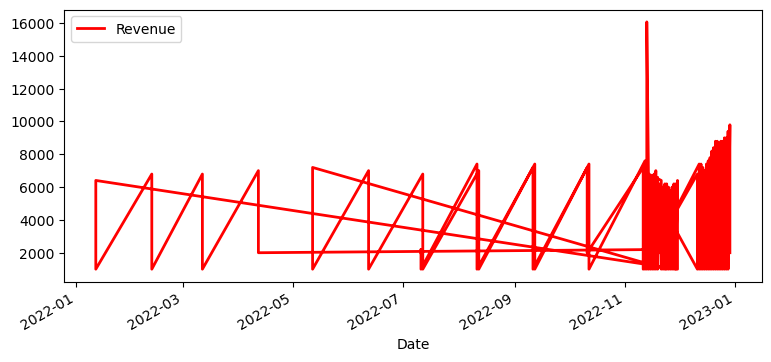

In [100]:
data.plot('Date','Revenue', color='red',linewidth=2,figsize=(9,4))
# set title etc

### Q5.What is the average revenue

In [105]:
data.Revenue.mean()

np.float64(3028.737952755905)

### Q6.What is the average Revenue of November & December month

In [107]:
data.head(3)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue
0,10452,2022-07-11,Fries,3.49,573,Online,Gift Card,Tom Jackson,London,1999.77
1,10453,2022-07-11,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid,2200.70
2,10454,2022-07-11,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon,998.00


In [111]:
data['Month']=data.Date.dt.month

In [112]:
data.head(2)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue,Month
0,10452,2022-07-11,Fries,3.49,573,Online,Gift Card,Tom Jackson,London,1999.77,7
1,10453,2022-07-11,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid,2200.70,7


In [116]:
m11=data[data.Month==11]
m11

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue,Month
16,10470,2022-11-11,Burgers,12.99,554,In-store,Credit Card,Pablo Perez,Madrid,7196.46,11
17,10471,2022-11-11,Chicken Sandwiches,9.95,201,In-store,Credit Card,Pablo Perez,Madrid,1999.95,11
18,10472,2022-11-11,Fries,3.49,630,In-store,Credit Card,Pablo Perez,Madrid,2198.70,11
19,10473,2022-11-11,Beverages,2.95,678,In-store,Credit Card,Pablo Perez,Madrid,2000.10,11
20,10474,2022-11-11,Sides & Other,4.99,200,In-store,Credit Card,Pablo Perez,Madrid,998.00,11
...,...,...,...,...,...,...,...,...,...,...,...
160,10620,2022-11-12,Burgers,12.99,585,Online,Gift Card,Tom Jackson,London,7599.15,11
161,10621,2022-11-12,Chicken Sandwiches,9.95,201,Online,Gift Card,Tom Jackson,London,1999.95,11
162,10622,2022-11-12,Fries,3.49,630,Online,Gift Card,Tom Jackson,London,2198.70,11
163,10623,2022-11-12,Beverages,2.95,746,Online,Gift Card,Tom Jackson,London,2200.70,11


In [117]:
m11.Revenue.mean()

np.float64(2969.3819587628864)

In [120]:
m12=data[data.Month==12]
m12

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue,Month
21,10475,2022-12-11,Burgers,12.99,523,In-store,Credit Card,Pablo Perez,Madrid,6793.77,12
22,10476,2022-12-11,Chicken Sandwiches,9.95,201,In-store,Credit Card,Pablo Perez,Madrid,1999.95,12
23,10477,2022-12-11,Fries,3.49,630,In-store,Credit Card,Pablo Perez,Madrid,2198.70,12
24,10478,2022-12-11,Beverages,2.95,678,In-store,Credit Card,Pablo Perez,Madrid,2000.10,12
25,10479,2022-12-11,Sides & Other,4.99,200,In-store,Credit Card,Pablo Perez,Madrid,998.00,12
...,...,...,...,...,...,...,...,...,...,...,...
249,10709,2022-12-28,Sides & Other,4.99,200,Drive-thru,Gift Card,Walter Muller,Berlin,998.00,12
250,10710,2022-12-29,Burgers,12.99,754,Drive-thru,Gift Card,Walter Muller,Berlin,9794.46,12
251,10711,2022-12-29,Chicken Sandwiches,9.95,281,Drive-thru,Gift Card,Walter Muller,Berlin,2795.95,12
252,10712,2022-12-29,Fries,3.49,630,Drive-thru,Gift Card,Walter Muller,Berlin,2198.70,12


In [122]:
m12.Revenue.mean()

np.float64(3194.7782978723403)

### Q7. Standardd Deviation of Revenue and Quantity

In [123]:
data.Quantity.std()

214.97943096363838

In [124]:
data.Revenue.std()

2419.9325462715055

### Q8.What is the variance of Revenue and Quantity

In [125]:
data.Revenue.var()

5856073.528504092

In [126]:
data.Quantity.var()

46216.155737449764

### Q9.Is Revenue increasing or decreasing over time

In [128]:
data.groupby('Month')['Revenue'].sum()

Month
1      13401.89
2      13990.52
3      13990.52
4       9001.56
5      14194.28
6      13999.43
7      19188.99
8      26600.38
9      28795.33
10     27797.33
11    288030.05
12    300309.16
Name: Revenue, dtype: float64

In [129]:
#its increasing over time

## Q10.Average Quantity sold & Average Revenue for each product

In [130]:
data.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue,Month
0,10452,2022-07-11,Fries,3.49,573,Online,Gift Card,Tom Jackson,London,1999.77,7
1,10453,2022-07-11,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid,2200.70,7
2,10454,2022-07-11,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon,998.00,7
3,10455,2022-08-11,Burgers,12.99,570,In-store,Credit Card,Walter Muller,Berlin,7404.30,8
4,10456,2022-08-11,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin,1999.95,8


In [136]:
data.groupby('Product')['Quantity','Revenue'].agg({'Quantity':'mean','Revenue':'mean'})

ValueError: Cannot subset columns with a tuple with more than one element. Use a list instead.

In [137]:
data.groupby('Product').agg(
    Avg_Quantity=('Quantity', 'mean'),
    Avg_Revenue=('Revenue', 'mean')
)


,Avg_Quantity,Avg_Revenue
Product,,
Beverages,699.760000,2064.292000
Burgers,558.038462,7248.919615
Chicken Sandwiches,214.096154,2204.085577
Fries,627.901961,2463.266078
Sides & Other,200.000000,998.000000
